# **03. [Breast] Survival Curves**

## **Introduction**
Generation of survival curves for the machine learning survival analysis (MLSA) models, along with the predictions from the XGB classification models from the previous study. The RSF and GBSA model curves are natively produced by the models, while the SSVM curve was adapted to represent probabilities over time. No curve adaptations were found for the XGB-Cox, XGB-AFT, and LGBM models that satisfied the theoretical assumptions.

## Environment Settings

In [ ]:
# download the file that contains the requirement management functions
!gdown 1563shEptjQS10FQbqjM-QsXot_cvHJBL --quiet
%run /content/bootstrap.py

# mount google drive
from google.colab import drive
drive.mount('/content/drive')

# put here the your Drive's path to the project
LOCAL_PROJECT_PATH = "/content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida"

set_project(LOCAL_PROJECT_PATH)
setup()

Mounted at /content/drive
Projeto definido: /content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida

Grupos disponíveis:
1. data_analysis
2. ml
3. Criar novo grupo

Escolha (ex: 1,3): 2

Lendo dependências de ml:
  - cmaes==0.13.0
  - lifelines==0.30.3
  - lightgbm==4.6.0
  - matplotlib==3.10.0
  - numpy==2.0.2
  - optuna==4.8.0
  - pandas==2.2.2
  - scikit-learn==1.8.0
  - scikit-survival==0.27.0
  - scipy==1.16.3
  - shap==0.51.0
  - xgboost==3.2.0

 Instalando dependências necessárias:
 + cmaes==0.13.0
 + lifelines==0.30.3
 + optuna==4.8.0
 + scikit-learn==1.8.0
 + scikit-survival==0.27.0
 + shap==0.51.0

⚠️ Dependências instaladas.
Reiniciando o kernel automaticamente...


<IPython.core.display.Javascript object>

In [ ]:
# Imports
import os
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib

from scipy.interpolate import interp1d

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler, QuantileTransformer
from sklearn.metrics import roc_curve, roc_auc_score, auc, ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

from sksurv.ensemble import RandomSurvivalForest
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw, brier_score
from sksurv.nonparametric import kaplan_meier_estimator

from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter

import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb

import optuna
from optuna.samplers import RandomSampler, TPESampler, CmaEsSampler

import shap

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

## Seed

In [ ]:
seed = 1

## Functions

In [ ]:
# Importing the functions
!gdown 1-uw7N4Vx5eNLso_NQ64uObFTlwXhdnda --quiet

from functions_ml_survival import *

# **Survival models**
Plot of the MLSA model curves.

## **Train e Test**

Dividing the database into training and testing components.

In [ ]:
# Breast Dataset
!gdown 11kKWTMoCH-m7U3n5CNrZbBs2zVePdciU --quiet

In [ ]:
# Reading data
df_mama = pd.read_csv('mama.csv')
print(df_mama.shape)
df_mama.head(3)

(155010, 51)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,PRESENCA_REC,PRESENCA_META,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag
0,8,4,65,3505708,9,1,C509,85003,I,I,...,1,0,0,0,1,1,1,1,1,121
1,8,9,44,3550308,9,2,C501,85003,IIA,II,...,1,0,0,1,1,1,1,1,1,121
2,8,4,46,3550308,9,2,C506,85003,IIA,II,...,0,0,0,0,1,1,1,1,1,121


In [ ]:
# Exclude patients with EC = 0 (In Situ)
df_mama = df_mama[df_mama.ECGRUP_CAT != 'In Situ']

# Exclude patients with morphology ending in 2
df_mama = df_mama[~df_mama['MORFO'].astype(str).str.endswith('2')]

# Exclude patients with morphology starting with 9
df_mama = df_mama[~df_mama.MORFO.isin([90703])]

df_mama.shape

(141727, 51)

In [ ]:
# Columns
df_mama.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV', 'TOPO',
       'MORFO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_REC', 'PRESENCA_META', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'sobrevida_ano7',
       'sobrevida_ano10', 'meses_diag'],
      dtype='object')

In [ ]:
# Overall Survival
df_mama['obito_geral'].value_counts()

,count
obito_geral,
0,95069
1,46658


In [ ]:
# Data Splitting into Training and Testing Sets
# Separate features (X) and target variable (y)
X = df_mama.drop(['obito_geral'], axis=1)  # Features (all columns except 'obito_geral')
y = df_mama['obito_geral']  # Target variable ('obito_geral')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% train, 20% test
                                                    random_state=seed,  # For reproducibility
                                                    stratify=y)  # Stratified sampling to maintain class proportions

# Print the shapes of the resulting datasets
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (113381, 50)
y_train: (113381,)
X_test: (28346, 50)
y_test: (28346,)


In [ ]:
# Saving the Datasets
# Concatenate features and target variable for training and testing sets
df_treino = pd.concat([X_train, y_train], axis=1)  # Combine X_train and y_train into a single DataFrame
df_teste = pd.concat([X_test, y_test], axis=1)  # Combine X_test and y_test into a single DataFrame

# Save the DataFrames to CSV files
df_treino.to_csv('mama_treino.csv', index=False)  # Save the training DataFrame to 'mama_treino.csv'
df_teste.to_csv('mama_teste.csv', index=False)  # Save the testing DataFrame to 'prostata_teste.csv'

## **Kaplan-Meier**

The Kaplan-Meier method will be used as the baseline for comparison with the survival model curves.

In [ ]:
# Reading Test Data
df_teste = pd.read_csv('mama_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(28346, 51)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,PRESENCA_REC,PRESENCA_META,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag,obito_geral
0,3,1,38,3530805,9,1,C509,85003,IIA,II,...,0,0,0,1,1,1,1,1,121,0
1,20737,9,38,3506102,9,1,C509,85003,IIIB,III,...,1,0,1,1,1,1,0,0,80,1
2,21636,4,62,3510203,2,1,C508,85003,IA,I,...,0,0,0,1,1,1,0,0,70,0


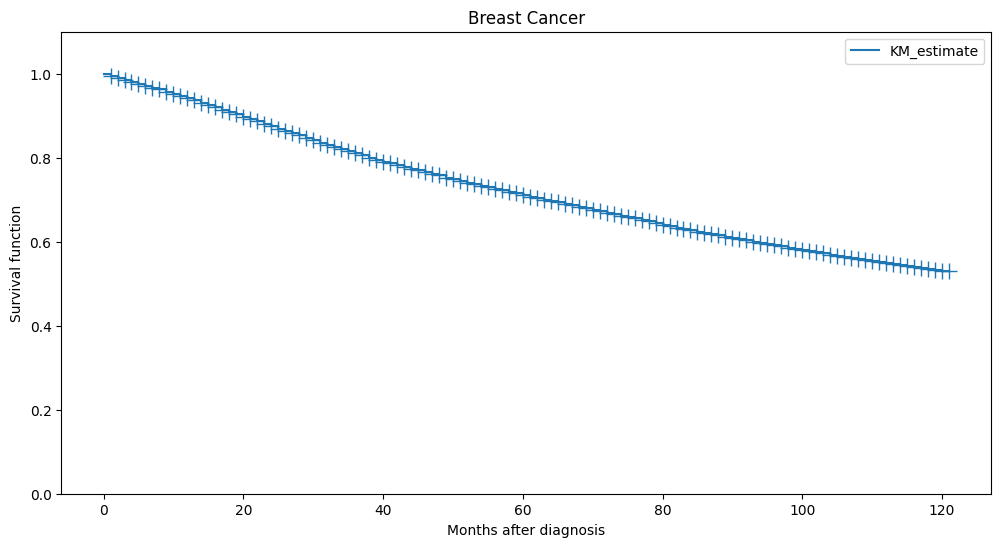

In [ ]:
# Kaplan-Meier Survival Curve Plot
# Extract event (E) and time (T) data from the test set
E = (df_teste.obito_geral == 1)  # Event indicator (obito_geral = 1 means event occurred)
T = df_teste.meses_diag  # Time to event (months since diagnosis)

title = f'Breast Cancer'  # Set the plot title

kmf = KaplanMeierFitter()  # Initialize the Kaplan-Meier fitter

fig = plt.figure(figsize=(12, 6))  # Create the plot figure
ax = plt.subplot(111)  # Create the axes for the plot

# Fit and plot the Kaplan-Meier survival curve
ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True)  # Fit the model, plot the curve, show censoring marks
ax.set_title(title)  # Set the plot title
ax.set_xlabel('Months after diagnosis')  # Set the x-axis label
ax.set_ylabel('Survival function')  # Set the y-axis label
plt.ylim([0, 1.1])  # Set y-axis limits
plt.show()  # Display the plot

In [ ]:
# Survival at 1, 3, 5, 7, and 10 Years
# Access survival probabilities at specific time points (12, 36, 60, 84, and 120 months)
kmf.survival_function_.iloc[[12, 36, 60, 84, 120]]

,KM_estimate
timeline,
12.0,0.942243
36.0,0.811058
60.0,0.710840
84.0,0.627515
120.0,0.529981


## **Machine Learning Survival**

Training of the 'best models' of the study, identified in the [survival models notebook](https://colab.research.google.com/drive/1lLK9RBvfdrGD5s-UcPrroYCmASsNvkII?usp=drive_link).

### **Data preparation for survival models**

In [ ]:
# Reading Training Data
df_treino = pd.read_csv('mama_treino.csv')  # Load the training data from the CSV file
print(df_treino.shape)  # Print the dimensions of the training DataFrame
df_treino.head(3)  # Display the first 3 rows of the training DataFrame

(113381, 51)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,PRESENCA_REC,PRESENCA_META,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag,obito_geral
0,275484,9,63,3518701,2,2,C508,85003,IIA,II,...,0,0,0,1,0,0,0,0,16,0
1,21636,2,58,3527405,2,1,C504,85003,IIA,II,...,0,0,0,1,1,0,0,0,47,1
2,22950,2,40,3540002,2,2,C502,85003,IIIB,III,...,0,0,0,1,1,1,1,0,98,0


In [ ]:
# Reading Test Data
df_teste = pd.read_csv('mama_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(28346, 51)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,PRESENCA_REC,PRESENCA_META,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag,obito_geral
0,3,1,38,3530805,9,1,C509,85003,IIA,II,...,0,0,0,1,1,1,1,1,121,0
1,20737,9,38,3506102,9,1,C509,85003,IIIB,III,...,1,0,1,1,1,1,0,0,80,1
2,21636,4,62,3510203,2,1,C508,85003,IA,I,...,0,0,0,1,1,1,0,0,70,0


In [ ]:
# Exclusion of the row where ULTDIAG was negative
df_treino = df_treino[df_treino.ULTIDIAG >= 0]
df_treino.shape

(113380, 51)

In [ ]:
# Y train and test for survival data (Death, Months from Diagnosis)
y_train = Surv.from_arrays(df_treino.obito_geral, df_treino.meses_diag)  # Create survival data for training set
y_test = Surv.from_arrays(df_teste.obito_geral, df_teste.meses_diag)  # Create survival data for test set

In [ ]:
# X train and test after removing unnecessary columns, including Death and Months from Diagnosis (which go to the target Y)
list_drop = ['sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'sobrevida_ano7',
             'sobrevida_ano10', 'obito_geral', 'obito_cancer', 'meses_diag',
             'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO', 'HORMONIO',
             'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
             'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
             'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST', 'RRAS_INST',
             'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META', 'PRESENCA_REC']

X_train = df_treino.drop(list_drop, axis=1)  # Remove specified columns from the training dataset

X_test = df_teste.drop(list_drop, axis=1)  # Remove specified columns from the test dataset

In [ ]:
# Preprocessing of Training and Test data
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Specify normalization method
                                                      return_enc_norm=True,  # Return encoder and normalizer objects
                                                      random_state=seed)  # Set random state for reproducibility

# Display the shapes of the processed training and test datasets
X_train.shape, X_test.shape

((113380, 16), (28346, 16))

In [ ]:
# Features columns
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV', 'TOPO',
       'MORFO', 'EC', 'ANODIAG', 'DRS', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

### **Modelos**

**RSF**

C-Index Test: 0.778357930378509
C-Index Train: 0.7926052001841516

C-Index IPCW Test: 0.7525375752096896
C-Index IPCW Train: 0.7677734550597117

Integrated Brier Score (IBS): 0.13350713441326195

Brier Score:
    > 1 year = 0.041941937599272235
    > 3 years = 0.11393887106831511
    > 5 years = 0.15057204690756884



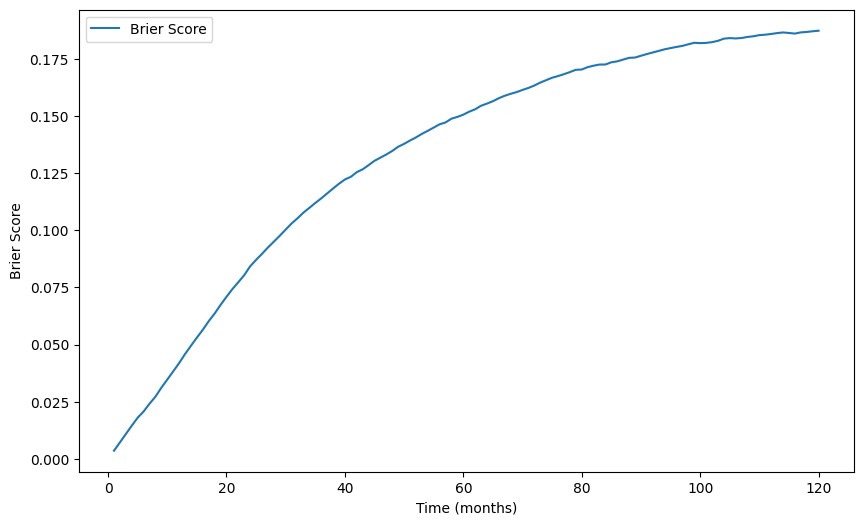

CPU times: user 2min 53s, sys: 13.2 s, total: 3min 6s
Wall time: 3min 17s


In [ ]:
%%time

rsf = RandomSurvivalForest(max_depth=12, min_samples_leaf=8, min_samples_split=7,
                           n_estimators=149, random_state=seed)

rsf.fit(X_train, y_train)

# Metrics of the best RSF model
final_c_index = rsf.score(X_test, y_test)  # Compute the final C-index for the test dataset

# Print the C-index for both test and training datasets
print(f'C-Index Test: {final_c_index}')
print(f'C-Index Train: {rsf.score(X_train, y_train)}\n')

# Compute and display the IPCW C-index and Brier Score for the best model
c_index_ipcw_brier_score(rsf, X_train, y_train, X_test, y_test)

**GBS**

C-Index Test: 0.782134682674239
C-Index Train: 0.8070386019441259

C-Index IPCW Test: 0.7564808535812949
C-Index IPCW Train: 0.7846280377637194

Integrated Brier Score (IBS): 0.13237858320719623

Brier Score:
    > 1 year = 0.04239313853731112
    > 3 years = 0.11329417360933276
    > 5 years = 0.1492069230555934



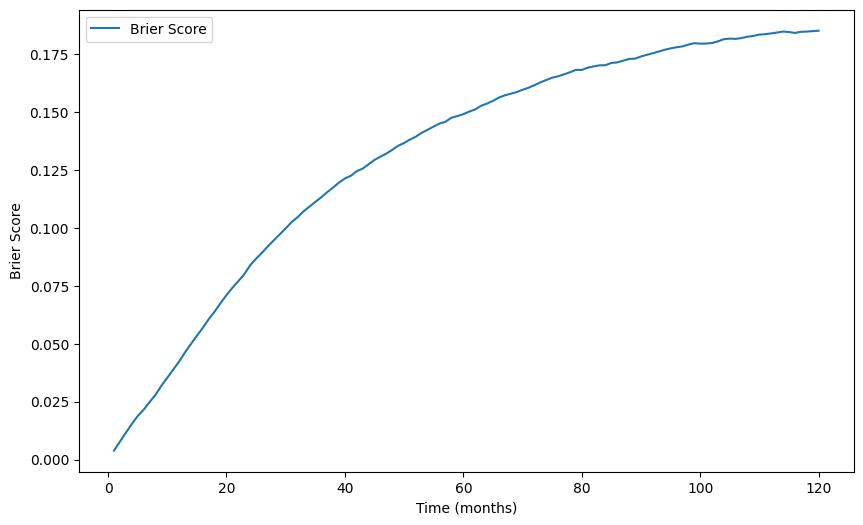

CPU times: user 7h 14min, sys: 9.91 s, total: 7h 14min 10s
Wall time: 7h 15min 51s


In [ ]:
%%time

gb = GradientBoostingSurvivalAnalysis(learning_rate=0.18, max_depth=8,
                                      max_features='sqrt', min_samples_leaf=2,
                                      min_samples_split=8, n_estimators=150,
                                      random_state=seed, subsample=0.8)
gb.fit(X_train, y_train)

# Metrics of the best GBS model
final_c_index = gb.score(X_test, y_test)  # Compute the C-index for the best model on the test dataset

print(f'C-Index Test: {final_c_index}')  # Print the C-index for the test set
print(f'C-Index Train: {gb.score(X_train, y_train)}\n')  # Print the C-index for the training set

# Calculate and print the IPCW and Brier score for the best model
c_index_ipcw_brier_score(gb, X_train, y_train, X_test, y_test)

In [ ]:
mama = {
    'gb': gb
}

with open('mama.pkl', 'wb') as f:
    pickle.dump(mama, f)

In [ ]:
with open('mama.pkl', 'rb') as f:
    mama = pickle.load(f)

mama

{'gb': GradientBoostingSurvivalAnalysis(learning_rate=0.18, max_depth=8,
                                  max_features='sqrt', min_samples_leaf=2,
                                  min_samples_split=8, n_estimators=150,
                                  random_state=1, subsample=0.8)}

**Survival SVM**

In [ ]:
%%time

ssvm = FastSurvivalSVM(optimizer='avltree', random_state=seed)
ssvm.fit(X_train, y_train)

# C-Index Calculation
print('C-Index')
print(f'> Test: {ssvm.score(X_test, y_test)}')  # Calculate and print the C-index for the test set
print(f'> Train: {ssvm.score(X_train, y_train)}')  # Calculate and print the C-index for the training set

# C-Index IPCW Calculation
surv_risks = ssvm.predict(X_test)  # Predict survival risks for the test set
surv_risks_train = ssvm.predict(X_train)  # Predict survival risks for the training set

# Compute IPCW C-index for test and train sets
c_index_ipcw = concordance_index_ipcw(y_train, y_test, surv_risks)  # IPCW C-index for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, surv_risks_train)  # IPCW C-index for the train set

print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')  # Print the IPCW C-index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print the IPCW C-index for the training set

C-Index
> Test: 0.7573846603956363
> Train: 0.7572716258541637

C-Index IPCW
> Test: 0.7301389813515528
> Train: 0.7312276433761006
CPU times: user 1min 16s, sys: 76.9 ms, total: 1min 16s
Wall time: 1min 17s


Nova versão da adaptação da curva (por calibração do modelo de Cox)

Brier Score at 12 months: 0.047827338474900026
Brier Score at 36 months: 0.1206712099580014
Brier Score at 60 months: 0.15859099959693004
Brier Score at 84 months: 0.1806581376403704
Brier Score at 120 months: 0.19957419559857079

Integrated Brier Score (IBS): 0.14147936725524946


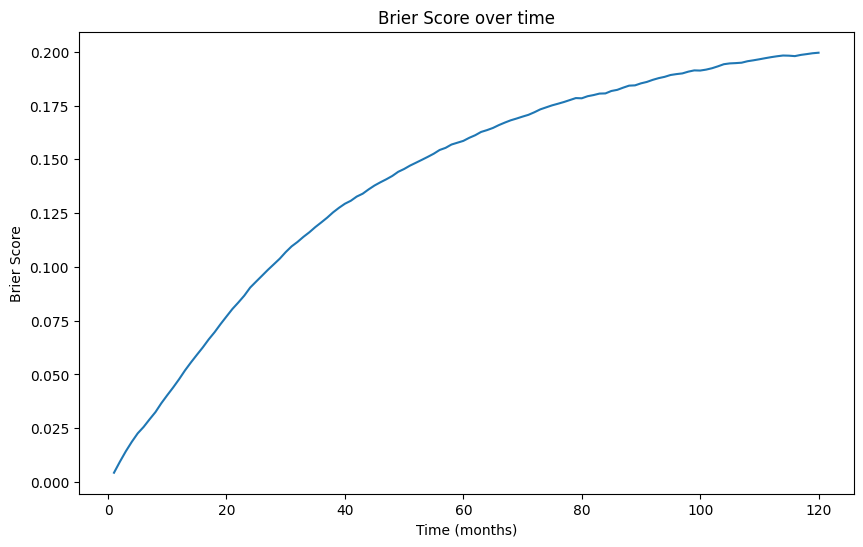

In [ ]:
from lifelines import CoxPHFitter
from sksurv.util import Surv

#Preparing dataframe for Cox Model training
event = y_test["event"]
time = y_test["time"]
df_cox = pd.DataFrame({
    "time": time,
    "event": event,
    "ssvm_score": surv_risks
})

#Fitting the Cox model with the predicted score as a covariate
cox = CoxPHFitter()
cox.fit(df_cox, duration_col="time", event_col="event")

# Generating individual curves (each column is a patient)
surv_funcs = cox.predict_survival_function(df_cox)
surv_funcs.drop(surv_funcs.index[-1], axis=0, inplace=True) #Censoring month 61
surv_ssvm_mean = surv_funcs.mean(axis=1)

#Brier Scores and Integrated Brier Score

time_points = np.arange(1, 121, 1)
surv_preds = surv_funcs.values.T

brier_scores = brier_score(
    y_train,  # Training data is used to estimate the censoring distribution
    y_test,   # Test data
    surv_preds,
    time_points
)

ibs = integrated_brier_score(
    y_train,
    y_test,
    surv_preds,
    time_points)

print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")
print(f"Brier Score at 84 months: {brier_scores[1][83]}")
print(f"Brier Score at 120 months: {brier_scores[1][119]}")
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1])
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score over time")
plt.show()

**XGBoost - Cox**

In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.1)  # Assign higher weights to events (1.0 for event and 0.1 for non-event)

params = {'n_estimators': 129, 'learning_rate': 0.13, 'max_depth': 6,
          'min_child_weight': 7, 'subsample': 0.8, 'colsample_bytree': 0.5,
          'reg_alpha': 0.01, 'reg_lambda': 0.001}  # Retrieve the best parameters from the study

params.update({'objective': 'survival:cox',  # Cox loss function for survival analysis
               'eval_metric': 'cox-nloglik',  # Evaluation metric for Cox model
               'random_state': seed,  # Set the random seed for reproducibility
               'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)  # DMatrix for training with weights
dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_cox = xgb.train(params, dtrain, num_boost_round=100, verbose_eval=False)

# Make predictions on the test and training datasets
y_pred = xgb_cox.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_cox.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # C-Index for test
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # C-Index for train

print('C-Index')  # Print label for C-Index
print(f'> Test: {c_index}')  # Print C-Index for the test set
print(f'> Train: {c_index_train}')  # Print C-Index for the training set

c_index_ipcw = concordance_index_ipcw(y_train, y_test, y_pred)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, y_pred_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7021298848983868
> Train: 0.715297889438881

C-Index IPCW
> Test: 0.6895613548956219
> Train: 0.6993745516618


Brier Score at 12 months: 0.04864699669362519
Brier Score at 36 months: 0.14181579121784096
Brier Score at 60 months: 0.19160437277272915
Brier Score at 84 months: 0.21986836922166914
Brier Score at 120 months: 0.23594904597099983

Integrated Brier Score (IBS): 0.16791912385143296


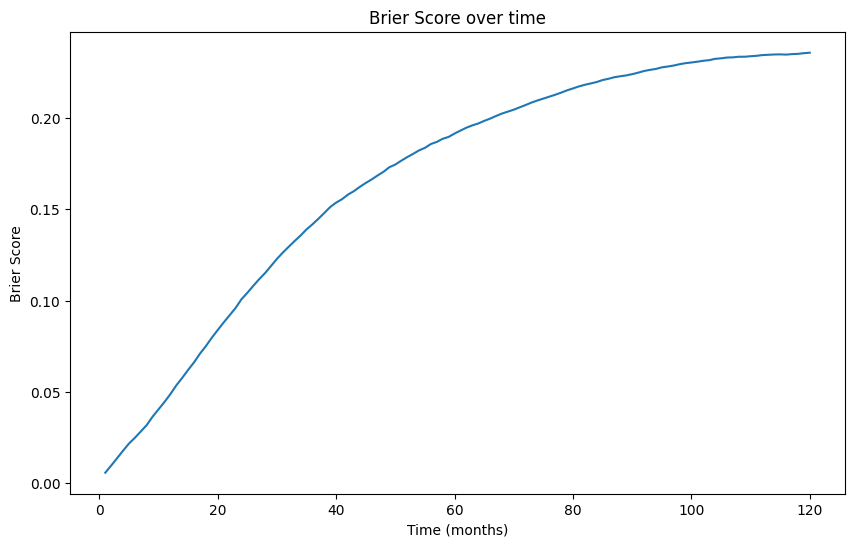

In [ ]:
# Center and standardize the risks (avoid min-max normalization)
scaler = StandardScaler()
surv_risks_scaled = scaler.fit_transform(y_pred.reshape(-1, 1)).flatten()

# Convert risks to hazard ratios (if the SSVM returns log-hazard values)
hazard_ratio = np.exp(surv_risks_scaled)  # Adjust this conversion as needed based on the model output

# Calculate the baseline survival curve on the training data using the Kaplan-Meier estimator
time_train, survival_prob_train = kaplan_meier_estimator(
    y_train["event"],
    y_train["time"]
)

# Compute the smoothed baseline hazard by taking the negative logarithm of the survival probability
baseline_hazard = -np.log(survival_prob_train + 1e-8)  # Add a small constant to avoid log(0)
baseline_hazard = np.nan_to_num(baseline_hazard, nan=0.0, posinf=0.0)  # Replace NaNs and infinities with 0

# Calculate S(t) = exp(-HR * H0(t)) for the test set, where HR is the hazard ratio and H0(t) is the baseline hazard
survival_probs_test = np.exp(-hazard_ratio[:, np.newaxis] * baseline_hazard)

# Define time points of interest (ensuring they fall within the observed range)
time_points = np.arange(1, 121, 1)  # From 1 to 120 months

# Perform stepwise interpolation (similar to Kaplan-Meier step functions)
interp_func = interp1d(
    time_train,
    survival_probs_test,
    kind='previous',  # Important for maintaining a step function behavior
    axis=1,
    bounds_error=False,
    fill_value=(1.0, 0.0)  # Conservative extrapolation: 1.0 before and 0.0 after the known range
)

# Obtain the interpolated survival probabilities for the defined time points
surv_probs_interp = interp_func(time_points)

# Enforce monotonicity: ensure survival probabilities do not increase over time
surv_probs_interp = np.minimum.accumulate(surv_probs_interp, axis=1)

# Clip values to ensure they are within valid bounds [0, 1]
surv_xgbcox_final = np.clip(surv_probs_interp, 0.0, 1.0)

# Calculate the Brier Score at the specified time points
brier_scores = brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_xgbcox_final,
    time_points
)

# Calculate the Integrated Brier Score (IBS) over the entire time range
ibs = integrated_brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_xgbcox_final,
    time_points
)

# Print the Brier Score at specific time points: 12, 36, 60, 84, and 120 months
print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")
print(f"Brier Score at 84 months: {brier_scores[1][83]}")
print(f"Brier Score at 120 months: {brier_scores[1][119]}")
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1])
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score over time")
plt.show()

**XGBoost - AFT**

In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.5)  # Assign higher weights to events (1.0 for event and 0.5 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

params = {'n_estimators': 86, 'learning_rate': 0.18, 'max_depth': 6,
          'min_child_weight': 6, 'subsample': 1.0, 'colsample_bytree': 0.8,
          'reg_alpha': 1, 'reg_lambda': 0.0001, 'aft_loss_distribution': 'normal',
          'aft_loss_distribution_scale': 1.25}  # Get the best parameters from the study

params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
               'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
               'random_state': seed,  # Seed for reproducibility
               'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_aft = xgb.train(params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_aft.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_aft.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

print('C-Index')  # Print label for C-Index
print(f'> Test: {c_index}')  # Print C-Index for the test set
print(f'> Train: {c_index_train}')  # Print C-Index for the training set

c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7844995688181111
> Train: 0.8033824798389494

C-Index IPCW
> Test: 0.7570433007168906
> Train: 0.7757009566575916


Brier Score at 12 months: 0.0822655101469067
Brier Score at 36 months: 0.2477109216831293
Brier Score at 60 months: 0.33936983352144295
Brier Score at 84 months: 0.39181379651334847
Brier Score at 120 months: 0.4174905618427708

Integrated Brier Score (IBS): 0.29651425807505977


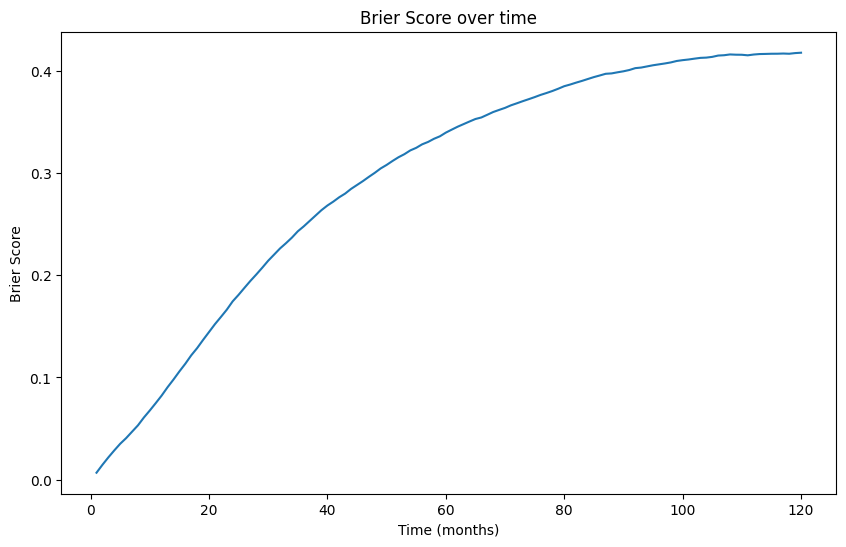

In [ ]:
# Standardize predicted risk scores using StandardScaler to ensure zero mean and unit variance
scaler = StandardScaler()
surv_risks_scaled = scaler.fit_transform(y_pred.reshape(-1, 1)).flatten()

# Convert standardized risk scores to hazard ratios using exponential transformation
hazard_ratio = np.exp(surv_risks_scaled)

# Calculate Kaplan-Meier survival probabilities for the training data
time_train, survival_prob_train = kaplan_meier_estimator(
    y_train["event"],
    y_train["time"]
)

# Compute baseline hazard by taking the negative log of survival probabilities (add small epsilon to avoid log(0))
# Replace NaN/Inf values with 0 to ensure numerical stability
baseline_hazard = -np.log(survival_prob_train + 1e-8)
baseline_hazard = np.nan_to_num(baseline_hazard, nan=0.0, posinf=0.0)

# Calculate survival probabilities for test data using hazard ratios and baseline hazard
survival_probs_test = np.exp(-hazard_ratio[:, np.newaxis] * baseline_hazard)

# Define time points for evaluation (1 to 120 months)
time_points = np.arange(1, 121, 1)

# Create interpolation function for survival probabilities using the training time grid
# Uses "previous" interpolation to align with stepwise nature of survival curves
interp_func = interp1d(
    time_train,
    survival_probs_test,
    kind='previous',
    axis=1,
    bounds_error=False,
    fill_value=(1.0, 0.0)  # Extend with 1.0 (survival) before first time point and 0.0 after last
)

# Interpolate survival probabilities to predefined monthly time points
surv_probs_interp = interp_func(time_points)
surv_probs_interp = np.minimum.accumulate(surv_probs_interp, axis=1)

# Clip survival probabilities to valid [0.0, 1.0] range
surv_xgbaft_final = np.clip(surv_probs_interp, 0.0, 1.0)

# Calculate the Brier Score at the specified time points
brier_scores = brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_xgbaft_final,
    time_points
)

# Calculate the Integrated Brier Score (IBS) over the entire time range
ibs = integrated_brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_xgbaft_final,
    time_points
)

# Print the Brier Score at specific time points: 12, 36, 60, 84, and 120 months
print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")
print(f"Brier Score at 84 months: {brier_scores[1][83]}")
print(f"Brier Score at 120 months: {brier_scores[1][119]}")
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1])
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score over time")
plt.show()

Gráfico - Permutation Importance e SHAP

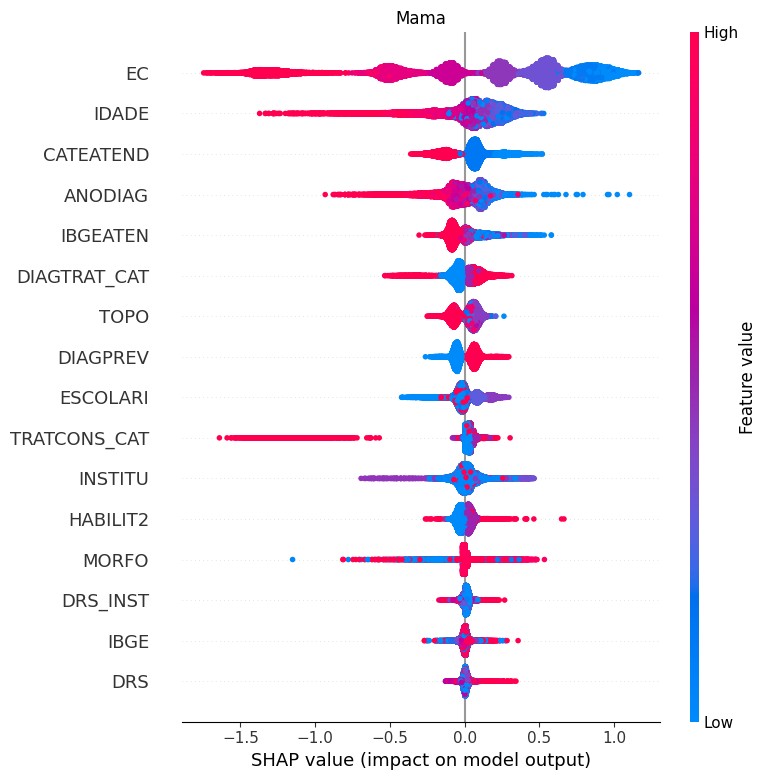

In [ ]:
# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(xgb_aft)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

plt.title('Mama')
# Generate a summary plot to visualize the SHAP values for each feature
shap.summary_plot(shap_values, X_test, feature_names=feat_cols, show=False)

plt.tight_layout()
plt.savefig("mama.svg");

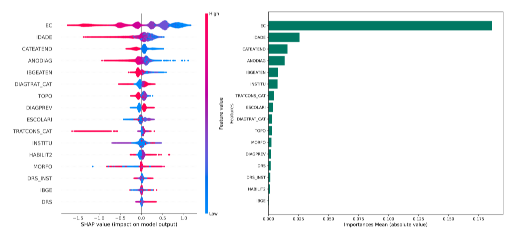

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.image as mpimg

# Best features by permutation importance
permutation_importance = calculate_permutation_importance_xgb(xgb_aft, X_test, y_test, feat_cols, random_state=seed)

# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(xgb_aft)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Save the SHAP summary_plot to a temporary file
shap.summary_plot(shap_values, X_test, feature_names=feat_cols, show=False)
plt.tight_layout()
plt.savefig("shap_plot.png", dpi=600, bbox_inches='tight')
plt.close()

# If 'feature' is in index, reset to column
if permutation_importance.index.name is not None:
    permutation_importance = permutation_importance.reset_index()

permutation_importance['features'] = permutation_importance.index

# Plot and save bar chart of your table
fig, ax = plt.subplots(figsize=(10,8))
permutation_importance_sorted = permutation_importance.sort_values('importances_mean', ascending=False)
ax.barh(permutation_importance_sorted['features'], permutation_importance_sorted['importances_mean'].abs(), color='#007863')
ax.set_xlabel('Importances Mean (absolute value)', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
# ax.set_title("Permutation Importance em módulo")
# fig.text(0.5, -0.02, 'Importances Mean (absolute value)', ha='center', fontsize=14)
# ax.invert_yaxis()  # mantém o mais importante no topo
plt.tight_layout()
plt.savefig("bar_plot.png", dpi=600, bbox_inches='tight')
plt.close()

# Open and combine images side by side with PIL
img1 = Image.open("shap_plot.png").convert("RGB")
img2 = Image.open("bar_plot.png").convert("RGB")

# Resize the height of the second image to match the height of the first (if necessary)
if img1.height != img2.height:
    img2 = img2.resize((img2.width, img1.height))

# Ensure same height
max_height = max(img1.height, img2.height)
total_width = img1.width + img2.width

# New combined image
combined_img = Image.new('RGB', (total_width, max_height), color=(255, 255, 255))
combined_img.paste(img1, (0, 0))
combined_img.paste(img2, (img1.width, 0))

# Save
combined_img.save("PI_SHAP_breast_charts.png", dpi=(300, 300), quality=95, optimize=True)
combined_img.save("PI_SHAP_breast_charts.eps", dpi=(300, 300), quality=95, optimize=True)

img = mpimg.imread("PI_SHAP_breast_charts.png")
plt.imshow(img)
plt.axis('off')
plt.show()

**LightGBM**

In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.15)  # Assign weights based on event occurrence (1.0 for events, 0.15 for censored data)

# Update the best parameters with the required model settings
params = {'n_estimators': 146, 'learning_rate': 0.1, 'max_depth': 7,
          'num_leaves': 73, 'min_child_samples': 12, 'subsample': 0.6,
          'colsample_bytree': 0.55, 'reg_alpha': 0.01, 'reg_lambda': 0.1}

params.update({'objective': 'regression',  # Use regression (Cox model) for survival analysis
               'metric': 'rmse',  # Metric for monitoring performance (Root Mean Squared Error)
               'seed': seed,  # Set the random seed for reproducibility
               'verbose': -1,  # Suppress output during training
               'n_jobs': -1})  # Use all available CPU cores for parallel computation

# Create the LightGBM dataset using the training data and weights
dtrain = lgb.Dataset(X_train, label=y_train['time'], weight=weights)
# dtest = xgb.DMatrix(X_test)  # You could use this for testing if needed, but it's not used here

# Train the LightGBM model with the best parameters found by Optuna
lgbm = lgb.train(params, dtrain, num_boost_round=100)

# Make predictions on the validation and training sets
y_pred = lgbm.predict(X_test)  # Predictions for the test set
y_pred_train = lgbm.predict(X_train)  # Predictions for the training set

# Calculate the Concordance Index (C-Index) for the test set
c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

print('C-Index')
print(f'> Test: {c_index}')  # Print the C-Index for the test set
print(f'> Train: {c_index_train}')  # Print the C-Index for the training set

# Calculate IPCW C-Index
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)  # Compute IPCW C-Index for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)  # Compute IPCW C-Index for the training set

# Display IPCW C-Index results
print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7132608872666698
> Train: 0.7333826019229964

C-Index IPCW
> Test: 0.6999553106912015
> Train: 0.7131837457961538


Brier Score at 12 months: 0.06846671491151123
Brier Score at 36 months: 0.25060591946953703
Brier Score at 60 months: 0.3839219035638772
Brier Score at 84 months: 0.46346175666686595
Brier Score at 120 months: 0.4957468173359174

Integrated Brier Score (IBS): 0.33454001169689596


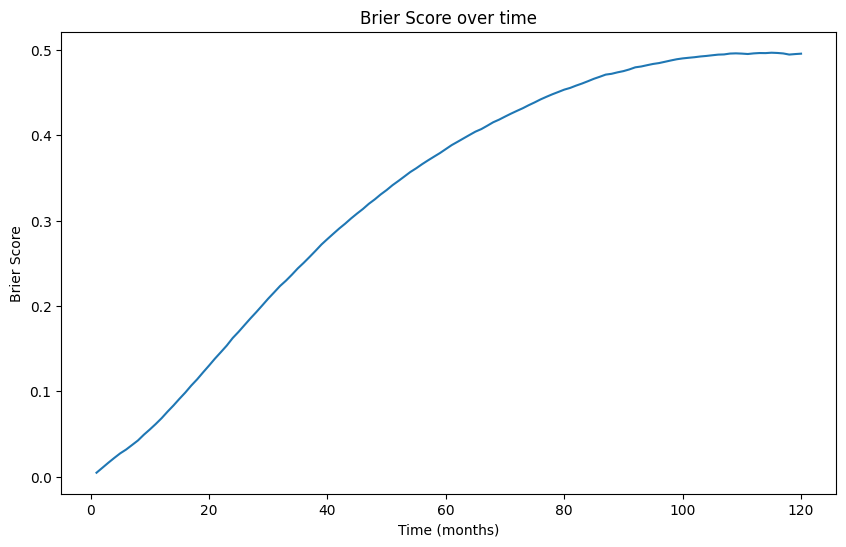

In [ ]:
# Standardize predicted risk scores using StandardScaler to ensure zero mean and unit variance
scaler = StandardScaler()
surv_risks_scaled = scaler.fit_transform(y_pred.reshape(-1, 1)).flatten()

# Convert standardized risk scores to hazard ratios using exponential transformation
hazard_ratio = np.exp(surv_risks_scaled)

# Calculate Kaplan-Meier survival probabilities for the training data
time_train, survival_prob_train = kaplan_meier_estimator(
    y_train["event"],
    y_train["time"]
)

# Compute baseline hazard by taking the negative log of survival probabilities (add small epsilon to avoid log(0))
# Replace NaN/Inf values with 0 to ensure numerical stability
baseline_hazard = -np.log(survival_prob_train + 1e-8)
baseline_hazard = np.nan_to_num(baseline_hazard, nan=0.0, posinf=0.0)

# Calculate survival probabilities for test data using hazard ratios and baseline hazard
survival_probs_test = np.exp(-hazard_ratio[:, np.newaxis] * baseline_hazard)

# Define time points for evaluation (1 to 120 months)
time_points = np.arange(1, 121, 1)

# Create interpolation function for survival probabilities using the training time grid
# Uses "previous" interpolation to align with stepwise nature of survival curves
interp_func = interp1d(
    time_train,
    survival_probs_test,
    kind='previous',
    axis=1,
    bounds_error=False,
    fill_value=(1.0, 0.0)  # Extend with 1.0 (survival) before first time point and 0.0 after last
)

# Interpolate survival probabilities to predefined monthly time points
surv_probs_interp = interp_func(time_points)
surv_probs_interp = np.minimum.accumulate(surv_probs_interp, axis=1)

# Clip survival probabilities to valid [0.0, 1.0] range
surv_lgbm_final = np.clip(surv_probs_interp, 0.0, 1.0)

# Calculate the Brier Score at the specified time points
brier_scores = brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_lgbm_final,
    time_points
)

# Calculate the Integrated Brier Score (IBS) over the entire time range
ibs = integrated_brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_lgbm_final,
    time_points
)

# Print the Brier Score at specific time points: 12, 36, 60, 84, and 120 months
print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")
print(f"Brier Score at 84 months: {brier_scores[1][83]}")
print(f"Brier Score at 120 months: {brier_scores[1][119]}")
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1])
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score over time")
plt.show()

# **Curves**
Plot final curves.

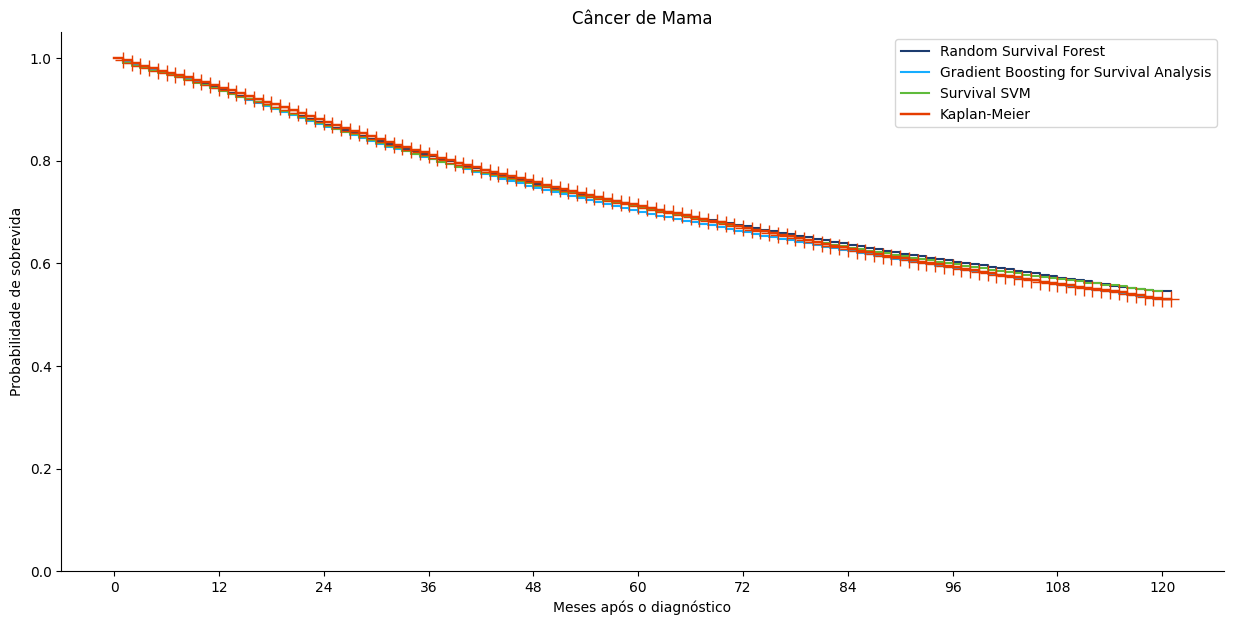

In [ ]:
# KM
fig = plt.figure(figsize=(15, 7))
ax = plt.subplot(111)

E = (df_teste.obito_geral == 1)  # Event indicator (obito_geral = 1 means event occurred)
T = df_teste.meses_diag  # Time to event (months since diagnosis)

colors = [
          '#E53D00',
          '#1B3B6F',
          '#15ADFF',
          '#5FBB3B'
        ]

times = rsf.unique_times_
lstyle = 'solid'

surv_rsf = rsf.predict_survival_function(X_test, return_array=True)
surv_rsf_mean = surv_rsf.mean(axis=0)
ax.step(times, surv_rsf_mean, linestyle=lstyle, color=colors[1],
        label='Random Survival Forest')

surv_gb = gb.predict_survival_function(X_test, return_array=True)
surv_gb_mean = surv_gb.mean(axis=0)
ax.step(times, surv_gb_mean, linestyle=lstyle, color=colors[2],
        label='Gradient Boosting for Survival Analysis')

# surv_ssvm_mean = surv_ssvm_final.mean(axis=0)
ax.step(times[:-1], surv_ssvm_mean, linestyle=lstyle, color=colors[3],
        label='Survival SVM')

ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True,
                        label='Kaplan-Meier', color=colors[0],
                        linewidth=1.75)

title = f'Câncer de Mama'  # Set the plot title
ax.set_title(title)
ax.set_xlabel('Meses após o diagnóstico')
ax.set_ylabel('Probabilidade de sobrevida')
ax.spines['top'].set_visible(False)  # Remove top border
ax.spines['right'].set_visible(False)  # Remove right border
plt.xticks(np.arange(0, rsf.unique_times_[-1] + 11, 12))  # Set x-axis ticks every 12 months
plt.ylim([0, 1.05])
plt.legend()

plt.savefig('mama.svg')

In [ ]:
from google.colab import files

files.download('mama.svg')
files.download('mama.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Results**

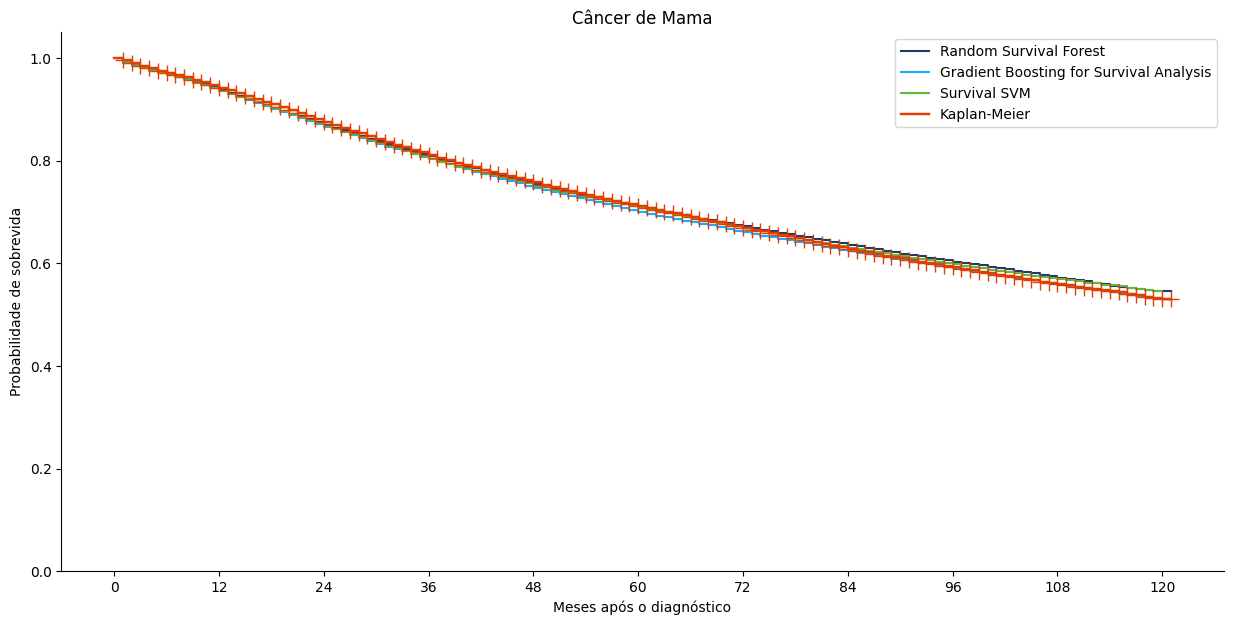

## Requirements Synchronization

In [ ]:
sync("ml", ["xgboost", "lightgbm", "scipy"])

[OK] xgboost já registrado (3.2.0)
[OK] lightgbm já registrado (4.6.0)
[OK] scipy já registrado (1.16.3)

Nenhuma alteração realizada.
